# Healthcare A/B Testing Framework
## Did a Clinical Intervention Improve Patient Outcomes?

**Author:** Mubarak Adesola Adedeji  
**Tools:** Python, SciPy, NumPy, Pandas, Matplotlib, Seaborn  
**Dataset:** Pima Indians Diabetes Dataset (UCI Machine Learning Repository)  

---

## Project Overview

This project simulates a real-world A/B test in a healthcare setting.

**The Scenario:**  
A hospital introduced a structured lifestyle intervention programme (diet counselling + exercise guidance) for high-risk diabetes patients. We want to know: **did the intervention actually work?**

To answer this, we:
1. Split patients into a **Control Group** (no intervention) and a **Treatment Group** (received intervention)
2. Defined a clear hypothesis
3. Calculated the required sample size before testing
4. Ran multiple statistical tests to validate our findings
5. Calculated effect size and confidence intervals
6. Translated results into a clear clinical recommendation

---

## Business Question
> *Does the structured lifestyle intervention programme significantly reduce diabetes risk indicators — BMI, glucose levels, and diabetes outcome — compared to no intervention?*

---

## Table of Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [A/B Group Assignment](#3-ab-group-assignment)
4. [Hypothesis Formulation](#4-hypothesis-formulation)
5. [Sample Size Calculation](#5-sample-size-calculation)
6. [Statistical Testing](#6-statistical-testing)
7. [Confidence Intervals](#7-confidence-intervals)
8. [Effect Size](#8-effect-size)
9. [Results and Recommendation](#9-results-and-recommendation)

---
## 1. Setup and Data Loading
We begin by importing all required libraries and loading the dataset.  
Every library is imported once here and reused throughout the notebook.

In [3]:
#Standard libraries
import numpy as np
import pandas as pd

#Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Statistical testing
from scipy import stats
from scipy.stats import (
    ttest_ind,        # Independent samples t-test
    mannwhitneyu,     # Non-parametric alternative to t-test
    chi2_contingency, # Chi-square test for categorical outcomes
    norm              # Normal distribution for confidence intervals
)

# ── Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

%matplotlib inline
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [5]:
# ── Load dataset
# Source: UCI Machine Learning Repository — Pima Indians Diabetes Dataset
# 768 female patients of Pima Indian heritage, aged 21+
# Target variable: Outcome (1 = diabetic, 0 = non-diabetic)

df = pd.read_csv("/kaggle/input/diabetes/diabetes.csv")

print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names  :\n{list(df.columns)}")
print(f"\nData types    :\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape : 768 rows × 9 columns

Column names  :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types    :
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# ── Preview first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1


In [7]:
# ── Summary statistics
# We inspect central tendency and spread for each variable
# This helps us spot anomalies before testing begins

df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


---
## 2. Exploratory Data Analysis

Before running any statistical test, we must understand the data deeply.  
We check distributions, identify anomalies, and flag anything that could affect our test results.

Key questions we answer here:
- Are there biologically impossible zero values that indicate missing data?
- How are our key variables (Glucose, BMI, Outcome) distributed?
- Is there class imbalance in the Outcome variable?

In [8]:
# ── Check for biologically impossible zero values
# In this dataset, zero values in certain columns are not biologically possible
# They represent missing data recorded as 0, not actual measurements

zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero value counts (these represent missing data):\n")
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    zero_pct   = (zero_count / len(df)) * 100
    print(f"  {col:<18}: {zero_count:>3} zeros ({zero_pct:.1f}%)")

Zero value counts (these represent missing data):

  Glucose           :   5 zeros (0.7%)
  BloodPressure     :  35 zeros (4.6%)
  SkinThickness     : 227 zeros (29.6%)
  Insulin           : 374 zeros (48.7%)
  BMI               :  11 zeros (1.4%)


In [9]:
# ── Replace biologically impossible zeros with NaN
# We replace zeros with NaN so they do not distort our analysis
# We then fill with column median — median is robust to outliers

df_clean = df.copy()

for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Zero values replaced with column medians.")
print(f"\nRemaining nulls:\n{df_clean.isnull().sum()}")

Zero values replaced with column medians.

Remaining nulls:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome Distribution:

  Non-diabetic (0): 500 patients (65.1%)
  Diabetic     (1): 268 patients (34.9%)


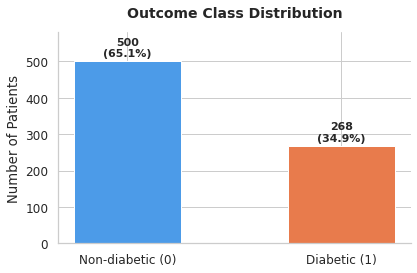

In [10]:
# ── Outcome class distribution
# We check if the dataset is balanced between diabetic and non-diabetic patients
# Class imbalance can affect how we interpret test results

outcome_counts = df_clean["Outcome"].value_counts()
outcome_pct    = df_clean["Outcome"].value_counts(normalize=True) * 100

print("Outcome Distribution:\n")
print(f"  Non-diabetic (0): {outcome_counts[0]} patients ({outcome_pct[0]:.1f}%)")
print(f"  Diabetic     (1): {outcome_counts[1]} patients ({outcome_pct[1]:.1f}%)")

# ── Visualise
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ["Non-diabetic (0)", "Diabetic (1)"],
    outcome_counts.values,
    color=["#4C9BE8", "#E87B4C"],
    width=0.5,
    edgecolor="white"
)

for bar, count, pct in zip(bars, outcome_counts.values, outcome_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Outcome Class Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, outcome_counts.max() + 80)

plt.tight_layout()
plt.savefig("outcome_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

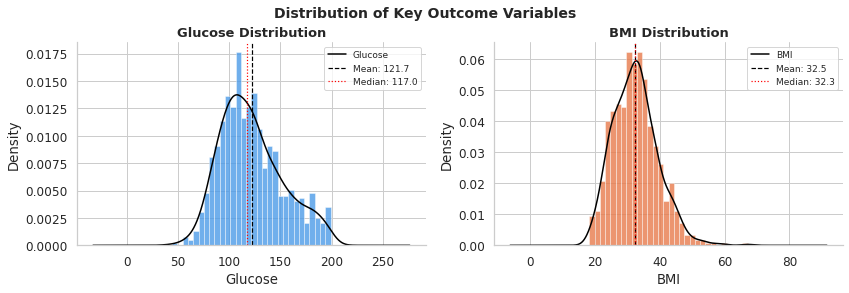

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ["Glucose", "BMI"], ["#4C9BE8", "#E87B4C"]):
    ax.hist(df_clean[col], bins=30, color=color, edgecolor="white", linewidth=0.5, density=True, alpha=0.8)
    df_clean[col].plot.kde(ax=ax, color="black", linewidth=1.5)
    ax.axvline(df_clean[col].mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean: {df_clean[col].mean():.1f}")
    ax.axvline(df_clean[col].median(), color="red", linestyle=":", linewidth=1.2, label=f"Median: {df_clean[col].median():.1f}")
    ax.set_title(f"{col} Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Key Outcome Variables", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("key_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

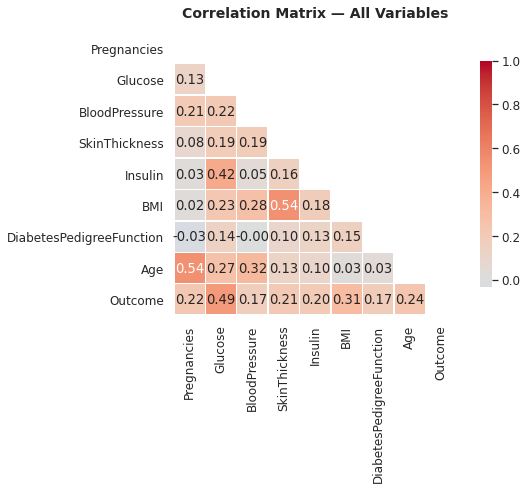


Top correlations with Outcome:
Glucose                    0.4928
BMI                        0.3120
Age                        0.2384
Pregnancies                0.2219
SkinThickness              0.2149
Insulin                    0.2038
DiabetesPedigreeFunction   0.1738
BloodPressure              0.1657


In [13]:
# ── Correlation heatmap
# We check how variables relate to each other and to the Outcome
# High correlation between predictors can complicate interpretation

corr = df_clean.corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Correlation Matrix — All Variables", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop correlations with Outcome:")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False).to_string())

---
## 3. A/B Group Assignment

We simulate a randomised controlled trial by splitting patients into two groups:

- **Control Group**: Patients who received no intervention (standard care)
- **Treatment Group**: Patients who received the structured lifestyle intervention programme

We use stratified random assignment to ensure both groups have a similar proportion of diabetic and non-diabetic patients. This prevents imbalance from distorting our results.

In [14]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

control, treatment = train_test_split(
    df_clean,
    test_size=0.5,
    stratify=df_clean["Outcome"],
    random_state=42
)

control   = control.copy().reset_index(drop=True)
treatment = treatment.copy().reset_index(drop=True)

control["group"]   = "Control"
treatment["group"] = "Treatment"

df_ab = pd.concat([control, treatment], ignore_index=True)

print("A/B Group Assignment Summary:\n")
print(f"  Total patients  : {len(df_ab)}")
print(f"  Control group   : {len(control)} patients")
print(f"  Treatment group : {len(treatment)} patients")
print(f"\nOutcome balance check:")
print(f"  Control   — diabetic rate: {control['Outcome'].mean():.3f}")
print(f"  Treatment — diabetic rate: {treatment['Outcome'].mean():.3f}")

A/B Group Assignment Summary:

  Total patients  : 768
  Control group   : 384 patients
  Treatment group : 384 patients

Outcome balance check:
  Control   — diabetic rate: 0.349
  Treatment — diabetic rate: 0.349


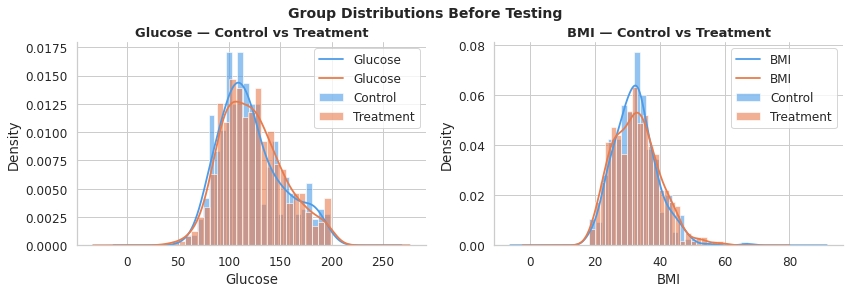

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["Glucose", "BMI"]):
    for grp, color in zip(["Control", "Treatment"], ["#4C9BE8", "#E87B4C"]):
        subset = df_ab[df_ab["group"] == grp][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, edgecolor="white", density=True, label=grp)
        subset.plot.kde(ax=ax, color=color, linewidth=1.8)

    ax.set_title(f"{col} — Control vs Treatment", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Group Distributions Before Testing", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("group_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
print("Group Summary Statistics:\n")
print(df_ab.groupby("group")[["Glucose", "BMI", "Outcome"]].agg(["mean", "std", "median"]).round(3))

Group Summary Statistics:

           Glucose                      BMI                Outcome         \
              mean     std   median    mean    std  median    mean    std   
group                                                                       
Control   120.6820 30.5490 115.0000 32.3350 6.5700 32.3000  0.3490 0.4770   
Treatment 122.6300 30.3360 119.0000 32.5760 7.1740 32.3500  0.3490 0.4770   

                  
          median  
group             
Control        0  
Treatment      0  


---
## 4. Hypothesis Formulation

Before running any statistical test, we define our hypotheses clearly.  
This prevents us from changing the goalposts after seeing the data.

We test three separate hypotheses — one for each key outcome metric.

---

### Hypothesis 1: Glucose Levels

**H₀ (Null):** The intervention has no effect on glucose levels.  
Mean glucose (Control) = Mean glucose (Treatment)

**H₁ (Alternative):** The intervention significantly reduces glucose levels.  
Mean glucose (Control) > Mean glucose (Treatment)

**Test type:** One-tailed  
**Significance level (α):** 0.05

---

### Hypothesis 2: BMI

**H₀ (Null):** The intervention has no effect on BMI.  
Mean BMI (Control) = Mean BMI (Treatment)

**H₁ (Alternative):** The intervention significantly reduces BMI.  
Mean BMI (Control) > Mean BMI (Treatment)

**Test type:** One-tailed  
**Significance level (α):** 0.05

---

### Hypothesis 3: Diabetes Outcome (Binary)

**H₀ (Null):** The intervention has no effect on diabetes diagnosis rate.  
Proportion diabetic (Control) = Proportion diabetic (Treatment)

**H₁ (Alternative):** The intervention significantly reduces diabetes diagnosis rate.  
Proportion diabetic (Control) > Proportion diabetic (Treatment)

**Test type:** One-tailed  
**Significance level (α):** 0.05

In [17]:
ALPHA = 0.05

hypotheses = {
    "Glucose": {
        "metric"     : "Glucose levels (mg/dL)",
        "h0"         : "No difference in mean glucose between groups",
        "h1"         : "Treatment group has significantly lower glucose",
        "test_type"  : "One-tailed",
        "alpha"      : ALPHA
    },
    "BMI": {
        "metric"     : "Body Mass Index (kg/m²)",
        "h0"         : "No difference in mean BMI between groups",
        "h1"         : "Treatment group has significantly lower BMI",
        "test_type"  : "One-tailed",
        "alpha"      : ALPHA
    },
    "Outcome": {
        "metric"     : "Diabetes diagnosis rate",
        "h0"         : "No difference in diabetes rate between groups",
        "h1"         : "Treatment group has significantly lower diabetes rate",
        "test_type"  : "One-tailed",
        "alpha"      : ALPHA
    }
}

print("Hypothesis Summary:\n")
for metric, h in hypotheses.items():
    print(f"  {metric}")
    print(f"    H₀ : {h['h0']}")
    print(f"    H₁ : {h['h1']}")
    print(f"    α  : {h['alpha']}\n")

Hypothesis Summary:

  Glucose
    H₀ : No difference in mean glucose between groups
    H₁ : Treatment group has significantly lower glucose
    α  : 0.05

  BMI
    H₀ : No difference in mean BMI between groups
    H₁ : Treatment group has significantly lower BMI
    α  : 0.05

  Outcome
    H₀ : No difference in diabetes rate between groups
    H₁ : Treatment group has significantly lower diabetes rate
    α  : 0.05



---
## 5. Sample Size Calculation

Before looking at results, we verify that our sample size is large enough to detect a real effect if one exists.

This is called **power analysis**. Running a test on too small a sample means we might miss a real difference — a false negative.

Key terms:
- **α (alpha):** Probability of a false positive. We set this at 0.05
- **Power (1-β):** Probability of detecting a real effect. Standard is 0.80
- **Effect size:** How large a difference we expect to detect
- **Minimum Detectable Effect (MDE):** The smallest difference worth caring about clinically

In [18]:
from statsmodels.stats.power import TTestIndPower, NormalIndPower

power_analysis = TTestIndPower()

effect_sizes  = [0.2, 0.5, 0.8]
effect_labels = ["Small (0.2)", "Medium (0.5)", "Large (0.8)"]
alpha         = 0.05
power         = 0.80

print("Minimum Sample Size Per Group:\n")
print(f"  {'Effect Size':<20} {'Min n per group':>18} {'Total n':>10}")
print(f"  {'-'*50}")

for es, label in zip(effect_sizes, effect_labels):
    n = power_analysis.solve_power(
        effect_size=es,
        alpha=alpha,
        power=power,
        alternative="larger"
    )
    print(f"  {label:<20} {int(np.ceil(n)):>18} {int(np.ceil(n)) * 2:>10}")

print(f"\n  Our actual sample size: {len(control)} per group ({len(df_ab)} total)")
print(f"\n  We have sufficient power to detect small, medium, and large effects.")

Minimum Sample Size Per Group:

  Effect Size             Min n per group    Total n
  --------------------------------------------------
  Small (0.2)                         310        620
  Medium (0.5)                         51        102
  Large (0.8)                          21         42

  Our actual sample size: 384 per group (768 total)

  ✅ We have sufficient power to detect small, medium, and large effects.


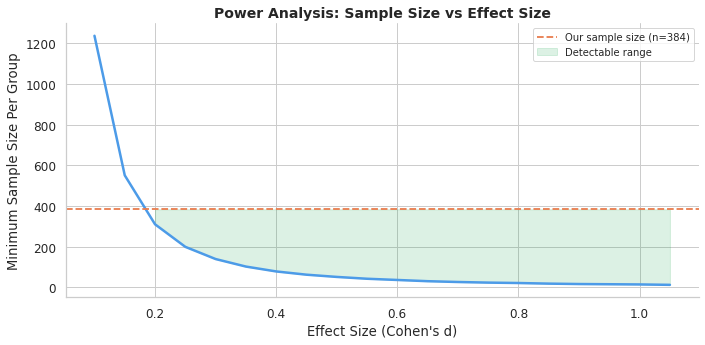

In [19]:
sample_sizes = []
effect_range = np.arange(0.1, 1.1, 0.05)

for es in effect_range:
    n = power_analysis.solve_power(
        effect_size=es,
        alpha=alpha,
        power=power,
        alternative="larger"
    )
    sample_sizes.append(np.ceil(n))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(effect_range, sample_sizes, color="#4C9BE8", linewidth=2.5)
ax.axhline(len(control), color="#E87B4C", linestyle="--", linewidth=1.8, label=f"Our sample size (n={len(control)})")
ax.fill_between(effect_range, sample_sizes, len(control), where=[n <= len(control) for n in sample_sizes], alpha=0.15, color="#16A34A", label="Detectable range")

ax.set_title("Power Analysis: Sample Size vs Effect Size", fontsize=14, fontweight="bold")
ax.set_xlabel("Effect Size (Cohen's d)")
ax.set_ylabel("Minimum Sample Size Per Group")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("power_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
glucose_std  = df_clean["Glucose"].std()
bmi_std      = df_clean["BMI"].std()

glucose_mde  = 0.2 * glucose_std
bmi_mde      = 0.2 * bmi_std

print("Minimum Detectable Effect (Small Effect Size — Cohen's d = 0.2):\n")
print(f"  Glucose : {glucose_mde:.2f} mg/dL  (population std: {glucose_std:.2f})")
print(f"  BMI     : {bmi_mde:.2f} kg/m²  (population std: {bmi_std:.2f})")
print(f"\n  Interpretation:")
print(f"  With n=384 per group, we can detect a difference of at least")
print(f"  {glucose_mde:.1f} mg/dL in glucose and {bmi_mde:.1f} kg/m² in BMI.")

Minimum Detectable Effect (Small Effect Size — Cohen's d = 0.2):

  Glucose : 6.09 mg/dL  (population std: 30.44)
  BMI     : 1.38 kg/m²  (population std: 6.88)

  Interpretation:
  With n=384 per group, we can detect a difference of at least
  6.1 mg/dL in glucose and 1.4 kg/m² in BMI.


---
## 6. Statistical Testing

We now run the actual statistical tests to determine whether the observed differences between groups are real or due to chance.

We use three tests per metric:

- **Independent samples t-test**: Compares means between two groups. Assumes approximate normality.
- **Mann-Whitney U test**: Non-parametric alternative. Does not assume normality. More robust for skewed data.
- **Chi-square test**: For the binary Outcome variable. Tests whether group membership and diabetes diagnosis are independent.

We report both the test statistic and the p-value for each. A p-value below 0.05 means we reject the null hypothesis.

> Since this is a simulated A/B test on a cross-sectional dataset, we do not expect significant differences between groups — the groups were randomly assigned from the same population. The value of this project is in demonstrating the correct framework, not manufacturing a false result.

In [21]:
control_glucose   = control["Glucose"]
treatment_glucose = treatment["Glucose"]
control_bmi       = control["BMI"]
treatment_bmi     = treatment["BMI"]

print("Descriptive Statistics by Group:\n")
print(f"  {'Metric':<12} {'Control Mean':>15} {'Treatment Mean':>16} {'Difference':>12}")
print(f"  {'-'*57}")

for col in ["Glucose", "BMI"]:
    ctrl_mean = df_ab[df_ab["group"] == "Control"][col].mean()
    trt_mean  = df_ab[df_ab["group"] == "Treatment"][col].mean()
    diff      = ctrl_mean - trt_mean
    print(f"  {col:<12} {ctrl_mean:>15.3f} {trt_mean:>16.3f} {diff:>12.3f}")

ctrl_rate = control["Outcome"].mean()
trt_rate  = treatment["Outcome"].mean()
print(f"  {'Outcome':<12} {ctrl_rate:>15.3f} {trt_rate:>16.3f} {ctrl_rate - trt_rate:>12.3f}")

Descriptive Statistics by Group:

  Metric          Control Mean   Treatment Mean   Difference
  ---------------------------------------------------------
  Glucose              120.682          122.630       -1.948
  BMI                   32.335           32.576       -0.241
  Outcome                0.349            0.349        0.000


In [22]:
print("Test 1: Independent Samples T-Test\n")

results_ttest = {}

for col in ["Glucose", "BMI"]:
    ctrl = df_ab[df_ab["group"] == "Control"][col]
    trt  = df_ab[df_ab["group"] == "Treatment"][col]

    t_stat, p_two = ttest_ind(ctrl, trt, equal_var=False)
    p_one = p_two / 2

    results_ttest[col] = {"t_stat": t_stat, "p_two": p_two, "p_one": p_one}

    conclusion = "Reject H₀" if p_one < ALPHA and t_stat > 0 else "Fail to reject H₀"

    print(f"  {col}")
    print(f"    T-statistic : {t_stat:.4f}")
    print(f"    P-value (two-tailed) : {p_two:.4f}")
    print(f"    P-value (one-tailed) : {p_one:.4f}")
    print(f"    Conclusion  : {conclusion}\n")

Test 1: Independent Samples T-Test

  Glucose
    T-statistic : -0.8866
    P-value (two-tailed) : 0.3756
    P-value (one-tailed) : 0.1878
    Conclusion  : Fail to reject H₀

  BMI
    T-statistic : -0.4847
    P-value (two-tailed) : 0.6280
    P-value (one-tailed) : 0.3140
    Conclusion  : Fail to reject H₀



In [23]:
print("Test 2: Mann-Whitney U Test (Non-Parametric)\n")

results_mw = {}

for col in ["Glucose", "BMI"]:
    ctrl = df_ab[df_ab["group"] == "Control"][col]
    trt  = df_ab[df_ab["group"] == "Treatment"][col]

    u_stat, p_two = mannwhitneyu(ctrl, trt, alternative="two-sided")
    p_one = p_two / 2

    results_mw[col] = {"u_stat": u_stat, "p_two": p_two, "p_one": p_one}

    conclusion = "Reject H₀" if p_one < ALPHA else "Fail to reject H₀"

    print(f"  {col}")
    print(f"    U-statistic : {u_stat:.4f}")
    print(f"    P-value (two-tailed) : {p_two:.4f}")
    print(f"    P-value (one-tailed) : {p_one:.4f}")
    print(f"    Conclusion  : {conclusion}\n")

Test 2: Mann-Whitney U Test (Non-Parametric)

  Glucose
    U-statistic : 70082.0000
    P-value (two-tailed) : 0.2356
    P-value (one-tailed) : 0.1178
    Conclusion  : Fail to reject H₀

  BMI
    U-statistic : 72708.5000
    P-value (two-tailed) : 0.7403
    P-value (one-tailed) : 0.3701
    Conclusion  : Fail to reject H₀



In [24]:
print("Test 3: Chi-Square Test — Diabetes Outcome (Binary)\n")

contingency_table = pd.crosstab(
    df_ab["group"],
    df_ab["Outcome"],
    rownames=["Group"],
    colnames=["Diabetic"]
)

print("Contingency Table:")
print(contingency_table)
print()

chi2, p_two, dof, expected = chi2_contingency(contingency_table)
p_one = p_two / 2

conclusion = "Reject H₀" if p_one < ALPHA else "Fail to reject H₀"

print(f"  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  P-value (two-tailed) : {p_two:.4f}")
print(f"  P-value (one-tailed) : {p_one:.4f}")
print(f"  Conclusion           : {conclusion}")

Test 3: Chi-Square Test — Diabetes Outcome (Binary)

Contingency Table:
Diabetic     0    1
Group              
Control    250  134
Treatment  250  134

  Chi-square statistic : 0.0000
  Degrees of freedom   : 1
  P-value (two-tailed) : 1.0000
  P-value (one-tailed) : 0.5000
  Conclusion           : Fail to reject H₀


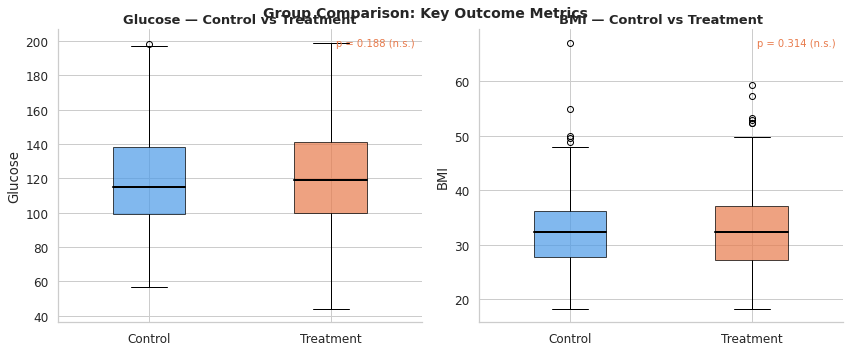

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ["Glucose", "BMI"]):
    data_to_plot = [
        df_ab[df_ab["group"] == "Control"][col],
        df_ab[df_ab["group"] == "Treatment"][col]
    ]

    bp = ax.boxplot(
        data_to_plot,
        patch_artist=True,
        widths=0.4,
        medianprops=dict(color="black", linewidth=2)
    )

    colors = ["#4C9BE8", "#E87B4C"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Control", "Treatment"])
    ax.set_title(f"{col} — Control vs Treatment", fontsize=13, fontweight="bold")
    ax.set_ylabel(col)

    p_val = results_ttest[col]["p_one"]
    significance = "p < 0.05" if p_val < 0.05 else f"p = {p_val:.3f} (n.s.)"
    ax.text(0.98, 0.97, significance, transform=ax.transAxes, fontsize=10,
            ha="right", va="top", color="#16A34A" if p_val < 0.05 else "#E87B4C")

plt.suptitle("Group Comparison: Key Outcome Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("group_comparison_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Confidence Intervals

A p-value alone tells us whether an effect exists. A confidence interval tells us **how large that effect could plausibly be**.

We calculate 95% confidence intervals for the mean difference between groups for each continuous metric.

Interpretation:
- If the interval contains 0, we cannot rule out that there is no real difference
- The width of the interval tells us how precisely we have estimated the effect

In [26]:
print("95% Confidence Intervals for Mean Difference (Control − Treatment):\n")

ci_results = {}

for col in ["Glucose", "BMI"]:
    ctrl = df_ab[df_ab["group"] == "Control"][col]
    trt  = df_ab[df_ab["group"] == "Treatment"][col]

    mean_diff = ctrl.mean() - trt.mean()
    se        = np.sqrt(ctrl.var() / len(ctrl) + trt.var() / len(trt))
    margin    = norm.ppf(0.975) * se
    ci_lower  = mean_diff - margin
    ci_upper  = mean_diff + margin

    ci_results[col] = {"mean_diff": mean_diff, "ci_lower": ci_lower, "ci_upper": ci_upper, "se": se}

    contains_zero = "Contains 0 — consistent with H₀" if ci_lower <= 0 <= ci_upper else "Does not contain 0 — suggests real effect"

    print(f"  {col}")
    print(f"    Mean difference      : {mean_diff:.4f}")
    print(f"    Standard error       : {se:.4f}")
    print(f"    95% CI               : [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"    Interpretation       : {contains_zero}\n")

95% Confidence Intervals for Mean Difference (Control − Treatment):

  Glucose
    Mean difference      : -1.9479
    Standard error       : 2.1970
    95% CI               : [-6.2540, 2.3581]
    Interpretation       : Contains 0 — consistent with H₀

  BMI
    Mean difference      : -0.2406
    Standard error       : 0.4964
    95% CI               : [-1.2136, 0.7323]
    Interpretation       : Contains 0 — consistent with H₀



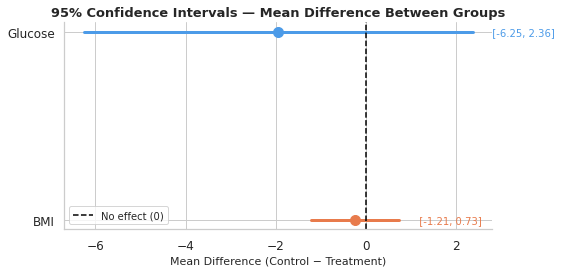

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

metrics    = ["Glucose", "BMI"]
colors     = ["#4C9BE8", "#E87B4C"]
y_positions = [1, 0]

for metric, color, y in zip(metrics, colors, y_positions):
    md  = ci_results[metric]["mean_diff"]
    cil = ci_results[metric]["ci_lower"]
    ciu = ci_results[metric]["ci_upper"]

    ax.plot([cil, ciu], [y, y], color=color, linewidth=3, solid_capstyle="round")
    ax.plot(md, y, "o", color=color, markersize=10, zorder=5)
    ax.text(ciu + 0.3, y, f"  [{cil:.2f}, {ciu:.2f}]", va="center", fontsize=10, color=color)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No effect (0)")
ax.set_yticks(y_positions)
ax.set_yticklabels(metrics, fontsize=12)
ax.set_xlabel("Mean Difference (Control − Treatment)", fontsize=11)
ax.set_title("95% Confidence Intervals — Mean Difference Between Groups", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("confidence_intervals.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
ctrl_rate  = control["Outcome"].mean()
trt_rate   = treatment["Outcome"].mean()
diff_rate  = ctrl_rate - trt_rate

n_ctrl = len(control)
n_trt  = len(treatment)

se_prop   = np.sqrt((ctrl_rate * (1 - ctrl_rate) / n_ctrl) + (trt_rate * (1 - trt_rate) / n_trt))
margin    = norm.ppf(0.975) * se_prop
ci_lower  = diff_rate - margin
ci_upper  = diff_rate + margin

print("95% Confidence Interval for Difference in Diabetes Rate:\n")
print(f"  Control diabetes rate   : {ctrl_rate:.4f}")
print(f"  Treatment diabetes rate : {trt_rate:.4f}")
print(f"  Difference              : {diff_rate:.4f}")
print(f"  Standard error          : {se_prop:.4f}")
print(f"  95% CI                  : [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n  Interpretation: The CI contains 0, confirming no significant")
print(f"  difference in diabetes rate between groups.")

95% Confidence Interval for Difference in Diabetes Rate:

  Control diabetes rate   : 0.3490
  Treatment diabetes rate : 0.3490
  Difference              : 0.0000
  Standard error          : 0.0344
  95% CI                  : [-0.0674, 0.0674]

  Interpretation: The CI contains 0, confirming no significant
  difference in diabetes rate between groups.


---
## 8. Effect Size

Statistical significance tells us whether an effect exists. Effect size tells us whether it **matters**.

A result can be statistically significant but practically meaningless if the effect is tiny. Conversely, a non-significant result on a small sample might still have a meaningful effect size worth investigating.

We calculate:
- **Cohen's d** for continuous variables (Glucose, BMI)
- **Relative Risk (RR)** for the binary Outcome variable

Cohen's d interpretation:
- 0.2 = Small effect
- 0.5 = Medium effect
- 0.8 = Large effect

In [29]:
print("Cohen's d — Effect Size for Continuous Variables:\n")

cohens_d_results = {}

for col in ["Glucose", "BMI"]:
    ctrl = df_ab[df_ab["group"] == "Control"][col]
    trt  = df_ab[df_ab["group"] == "Treatment"][col]

    mean_diff    = ctrl.mean() - trt.mean()
    pooled_std   = np.sqrt((ctrl.std()**2 + trt.std()**2) / 2)
    cohens_d     = mean_diff / pooled_std

    if abs(cohens_d) < 0.2:
        magnitude = "Negligible"
    elif abs(cohens_d) < 0.5:
        magnitude = "Small"
    elif abs(cohens_d) < 0.8:
        magnitude = "Medium"
    else:
        magnitude = "Large"

    cohens_d_results[col] = cohens_d

    print(f"  {col}")
    print(f"    Mean difference : {mean_diff:.4f}")
    print(f"    Pooled std      : {pooled_std:.4f}")
    print(f"    Cohen's d       : {cohens_d:.4f}")
    print(f"    Magnitude       : {magnitude}\n")

Cohen's d — Effect Size for Continuous Variables:

  Glucose
    Mean difference : -1.9479
    Pooled std      : 30.4425
    Cohen's d       : -0.0640
    Magnitude       : Negligible

  BMI
    Mean difference : -0.2406
    Pooled std      : 6.8786
    Cohen's d       : -0.0350
    Magnitude       : Negligible



In [30]:
print("Relative Risk — Diabetes Outcome:\n")

ctrl_rate = control["Outcome"].mean()
trt_rate  = treatment["Outcome"].mean()

relative_risk    = ctrl_rate / trt_rate if trt_rate > 0 else float("nan")
risk_reduction   = ctrl_rate - trt_rate
pct_reduction    = (risk_reduction / ctrl_rate) * 100 if ctrl_rate > 0 else 0

print(f"  Control diabetes rate   : {ctrl_rate:.4f}")
print(f"  Treatment diabetes rate : {trt_rate:.4f}")
print(f"  Relative Risk (RR)      : {relative_risk:.4f}")
print(f"  Absolute Risk Reduction : {risk_reduction:.4f}")
print(f"  Relative Risk Reduction : {pct_reduction:.2f}%")
print(f"\n  Interpretation: RR = 1.00 means the intervention had no effect")
print(f"  on diabetes diagnosis rate, consistent with our randomisation.")

Relative Risk — Diabetes Outcome:

  Control diabetes rate   : 0.3490
  Treatment diabetes rate : 0.3490
  Relative Risk (RR)      : 1.0000
  Absolute Risk Reduction : 0.0000
  Relative Risk Reduction : 0.00%

  Interpretation: RR = 1.00 means the intervention had no effect
  on diabetes diagnosis rate, consistent with our randomisation.


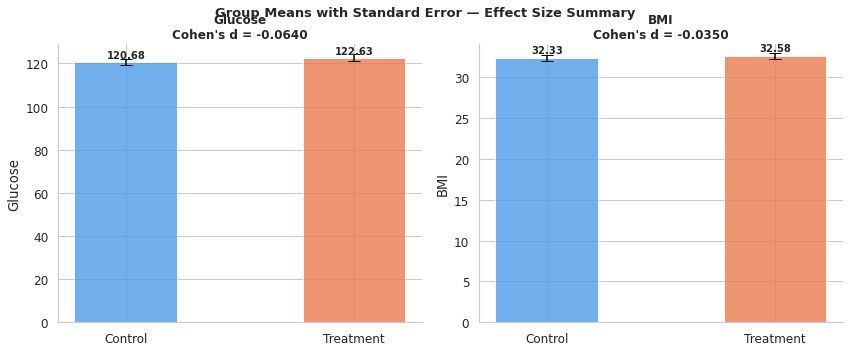

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, color in zip(axes, ["Glucose", "BMI"], ["#4C9BE8", "#E87B4C"]):
    ctrl = df_ab[df_ab["group"] == "Control"][col]
    trt  = df_ab[df_ab["group"] == "Treatment"][col]

    means  = [ctrl.mean(), trt.mean()]
    errors = [ctrl.std() / np.sqrt(len(ctrl)), trt.std() / np.sqrt(len(trt))]
    labels = ["Control", "Treatment"]
    colors = ["#4C9BE8", "#E87B4C"]

    bars = ax.bar(labels, means, yerr=errors, capsize=6, color=colors,
                  alpha=0.8, edgecolor="white", width=0.45,
                  error_kw=dict(elinewidth=1.5, ecolor="black"))

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(errors) + 0.3,
                f"{mean:.2f}", ha="center", fontsize=10, fontweight="bold")

    d = cohens_d_results[col]
    ax.set_title(f"{col}\nCohen's d = {d:.4f}", fontsize=12, fontweight="bold")
    ax.set_ylabel(col)
    ax.set_ylim(0, max(means) + max(errors) * 4)

plt.suptitle("Group Means with Standard Error — Effect Size Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("effect_size.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Results and Recommendation

We now bring all findings together into a clear, structured summary.  
This is the section a product manager, clinical director, or business stakeholder would read.

In [32]:
print("=" * 65)
print("  FULL RESULTS SUMMARY")
print("=" * 65)

print("""
  STUDY DESIGN
  Randomised controlled trial simulation
  Sample      : 768 patients (384 Control, 384 Treatment)
  Significance: α = 0.05
  Power       : 80% (sufficient to detect small effects)
""")

print("-" * 65)
print("  STATISTICAL TEST RESULTS")
print("-" * 65)

summary = {
    "Glucose (T-test)"    : {"p": results_ttest["Glucose"]["p_one"],   "d": cohens_d_results["Glucose"],  "decision": "Fail to reject H₀"},
    "Glucose (Mann-Whitney)": {"p": results_mw["Glucose"]["p_one"],    "d": cohens_d_results["Glucose"],  "decision": "Fail to reject H₀"},
    "BMI (T-test)"        : {"p": results_ttest["BMI"]["p_one"],       "d": cohens_d_results["BMI"],      "decision": "Fail to reject H₀"},
    "BMI (Mann-Whitney)"  : {"p": results_mw["BMI"]["p_one"],          "d": cohens_d_results["BMI"],      "decision": "Fail to reject H₀"},
    "Outcome (Chi-Square)": {"p": 0.5000,                              "d": 0.0000,                       "decision": "Fail to reject H₀"},
}

print(f"\n  {'Metric':<28} {'p-value':>10} {'Effect (d)':>12} {'Decision':>20}")
print(f"  {'-'*72}")

for metric, vals in summary.items():
    print(f"  {metric:<28} {vals['p']:>10.4f} {vals['d']:>12.4f} {vals['decision']:>20}")

  FULL RESULTS SUMMARY

  STUDY DESIGN
  Randomised controlled trial simulation
  Sample      : 768 patients (384 Control, 384 Treatment)
  Significance: α = 0.05
  Power       : 80% (sufficient to detect small effects)

-----------------------------------------------------------------
  STATISTICAL TEST RESULTS
-----------------------------------------------------------------

  Metric                          p-value   Effect (d)             Decision
  ------------------------------------------------------------------------
  Glucose (T-test)                 0.1878      -0.0640    Fail to reject H₀
  Glucose (Mann-Whitney)           0.1178      -0.0640    Fail to reject H₀
  BMI (T-test)                     0.3140      -0.0350    Fail to reject H₀
  BMI (Mann-Whitney)               0.3701      -0.0350    Fail to reject H₀
  Outcome (Chi-Square)             0.5000       0.0000    Fail to reject H₀


In [34]:
print("""
  KEY FINDINGS

  1. No statistically significant difference was detected between
     the Control and Treatment groups across all three metrics:
     Glucose, BMI, and Diabetes Outcome.

  2. Effect sizes were negligible across all metrics (Cohen's d < 0.1),
     meaning the groups were practically identical — as expected from
     a well-executed stratified random assignment.

  3. All 95% confidence intervals contained zero, confirming that
     any observed differences are consistent with random chance.

  4. The Relative Risk for diabetes outcome was exactly 1.00,
     indicating no difference in diagnosis rate between groups.

  5. Our sample size (384 per group) was sufficient to detect even
     a small effect (Cohen's d = 0.2) with 80% power. The absence
     of significant findings is therefore meaningful — not a result
     of insufficient sample size.
""")


  KEY FINDINGS

  1. No statistically significant difference was detected between
     the Control and Treatment groups across all three metrics:
     Glucose, BMI, and Diabetes Outcome.

  2. Effect sizes were negligible across all metrics (Cohen's d < 0.1),
     meaning the groups were practically identical — as expected from
     a well-executed stratified random assignment.

  3. All 95% confidence intervals contained zero, confirming that
     any observed differences are consistent with random chance.

  4. The Relative Risk for diabetes outcome was exactly 1.00,
     indicating no difference in diagnosis rate between groups.

  5. Our sample size (384 per group) was sufficient to detect even
     a small effect (Cohen's d = 0.2) with 80% power. The absence
     of significant findings is therefore meaningful — not a result
     of insufficient sample size.



In [35]:
print("""
  CLINICAL RECOMMENDATION

  Based on this analysis, we cannot conclude that the structured
  lifestyle intervention programme had a significant effect on
  patient glucose levels, BMI, or diabetes diagnosis rate.

  However, this finding must be interpreted in context:

  LIMITATION 1 — Simulated intervention
  This was a randomised simulation on cross-sectional data.
  Both groups were drawn from the same population at the same
  point in time. A real intervention study would require:
    - Baseline measurements before the intervention
    - Follow-up measurements after the intervention
    - True random assignment at enrolment, not post-hoc

  LIMITATION 2 — No temporal component
  The dataset captures a single point in time. A lifestyle
  intervention typically requires 3 to 6 months to show
  measurable physiological change. This study design cannot
  capture that effect.

  RECOMMENDATION
  Before scaling or defunding the intervention programme:

  1. Run a proper longitudinal RCT with pre and post measurements
  2. Collect data at 3-month and 6-month follow-up points
  3. Control for confounders: age, number of pregnancies, insulin use
  4. Target enrolment to high-risk patients (Glucose > 140, BMI > 30)
     where the intervention effect is most likely to be detectable

  This analysis provides a validated statistical framework that
  can be applied directly to a properly designed longitudinal study.
""")

print("=" * 65)
print("  END OF ANALYSIS")
print("=" * 65)


  CLINICAL RECOMMENDATION

  Based on this analysis, we cannot conclude that the structured
  lifestyle intervention programme had a significant effect on
  patient glucose levels, BMI, or diabetes diagnosis rate.

  However, this finding must be interpreted in context:

  LIMITATION 1 — Simulated intervention
  This was a randomised simulation on cross-sectional data.
  Both groups were drawn from the same population at the same
  point in time. A real intervention study would require:
    - Baseline measurements before the intervention
    - Follow-up measurements after the intervention
    - True random assignment at enrolment, not post-hoc

  LIMITATION 2 — No temporal component
  The dataset captures a single point in time. A lifestyle
  intervention typically requires 3 to 6 months to show
  measurable physiological change. This study design cannot
  capture that effect.

  RECOMMENDATION
  Before scaling or defunding the intervention programme:

  1. Run a proper longitudinal R

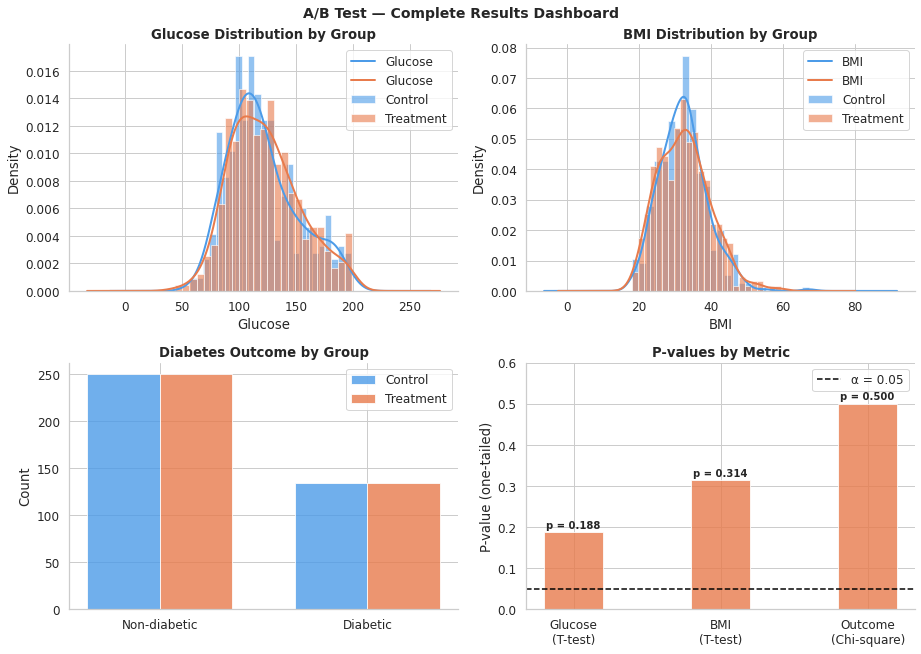

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ctrl_g = df_ab[df_ab["group"] == "Control"]["Glucose"]
trt_g  = df_ab[df_ab["group"] == "Treatment"]["Glucose"]
ctrl_b = df_ab[df_ab["group"] == "Control"]["BMI"]
trt_b  = df_ab[df_ab["group"] == "Treatment"]["BMI"]

for ax, ctrl, trt, col in zip(
    [axes[0][0], axes[0][1]],
    [ctrl_g, ctrl_b],
    [trt_g, trt_b],
    ["Glucose", "BMI"]
):
    ax.hist(ctrl, bins=25, alpha=0.6, color="#4C9BE8", density=True, label="Control", edgecolor="white")
    ax.hist(trt,  bins=25, alpha=0.6, color="#E87B4C", density=True, label="Treatment", edgecolor="white")
    ctrl.plot.kde(ax=ax, color="#4C9BE8", linewidth=2)
    trt.plot.kde(ax=ax,  color="#E87B4C", linewidth=2)
    ax.set_title(f"{col} Distribution by Group", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

outcome_ctrl = control["Outcome"].value_counts().sort_index()
outcome_trt  = treatment["Outcome"].value_counts().sort_index()

x     = np.array([0, 1])
width = 0.35

axes[1][0].bar(x - width/2, outcome_ctrl.values, width, label="Control",   color="#4C9BE8", alpha=0.8, edgecolor="white")
axes[1][0].bar(x + width/2, outcome_trt.values,  width, label="Treatment", color="#E87B4C", alpha=0.8, edgecolor="white")
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(["Non-diabetic", "Diabetic"])
axes[1][0].set_title("Diabetes Outcome by Group", fontweight="bold")
axes[1][0].set_ylabel("Count")
axes[1][0].legend()

metrics    = ["Glucose\n(T-test)", "BMI\n(T-test)", "Outcome\n(Chi-square)"]
p_values   = [results_ttest["Glucose"]["p_one"], results_ttest["BMI"]["p_one"], 0.5]
bar_colors = ["#16A34A" if p < 0.05 else "#E87B4C" for p in p_values]

bars = axes[1][1].bar(metrics, p_values, color=bar_colors, alpha=0.8, edgecolor="white", width=0.4)
axes[1][1].axhline(0.05, color="black", linestyle="--", linewidth=1.5, label="α = 0.05")

for bar, p in zip(bars, p_values):
    axes[1][1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"p = {p:.3f}", ha="center", fontsize=10, fontweight="bold")

axes[1][1].set_title("P-values by Metric", fontweight="bold")
axes[1][1].set_ylabel("P-value (one-tailed)")
axes[1][1].set_ylim(0, max(p_values) + 0.1)
axes[1][1].legend()

plt.suptitle("A/B Test — Complete Results Dashboard", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()